In [13]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

In [14]:
from src.utils.io import load_excel

DATA_DIR = PROJECT_ROOT / "data"

dataset = load_excel(
    DATA_DIR /
    "processed" /
    "processed_elec-prot" /
    "elec-prot.xlsx"
)

In [15]:
features = ["MDR", "PW", "Frequency", "NoP", "TD", "Particle", "Target"]

X= dataset[features]
y = dataset["Endpoint"]

titles = dataset["Title"]

In [ ]:
"""
The dataset is partitioned into 7 subsets. From this partitioning, seven distinct dataframes are generated, each corresponding 
to a different fold in which one subset is used as the validation set and the remaining six subsets constitute the training set.
Data augmentation is performed by generating four variants for each instance. This choice compensates for the reduced amount of 
training data when using seven folds instead of five.


For future reference, the StandardScaler must be fitted exclusively on the training data. After fitting the scaler and training 
the model on the scaled training set, the validation set should be transformed using the scaler parameters derived from the 
training data.
"""

In [ ]:
from src.models.augmentation_df import build_augmented_kfold_datasets
number_of_folds = 7
datasets = build_augmented_kfold_datasets(
    X=X,
    y=y,
    num_variants=4,       # number of augmented instances
    n_splits=number_of_folds,  
    random_state=1 
)

In [ ]:
"""  
The distribution of the features was plotted for each fold to highlight potential differences between the training and validation 
sets. This analysis proved useful for adjusting the augmentation parameters, ultimately leading to the decision to apply the same 
sigma value (0.001) across all features.
"""

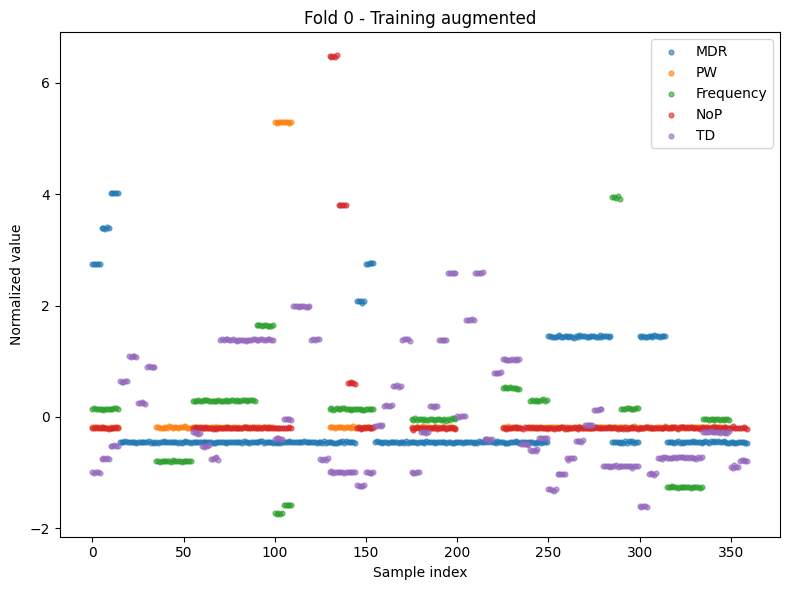

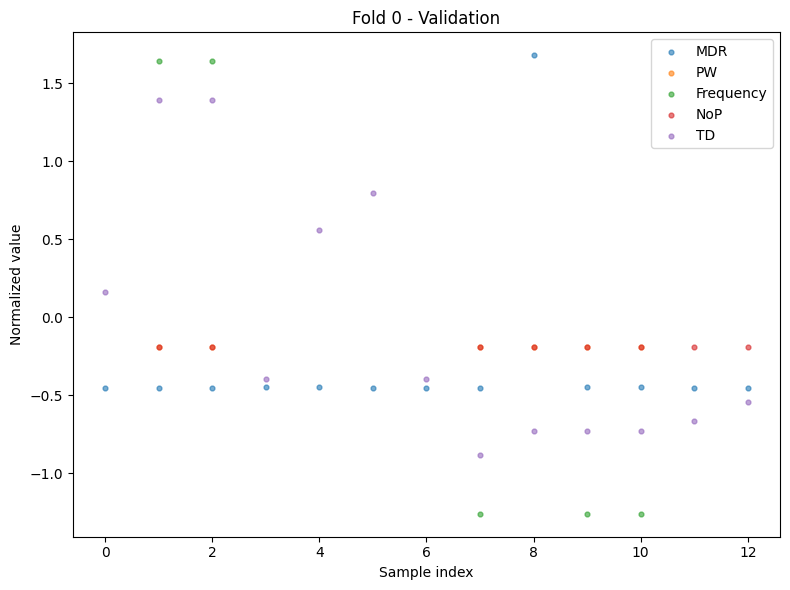

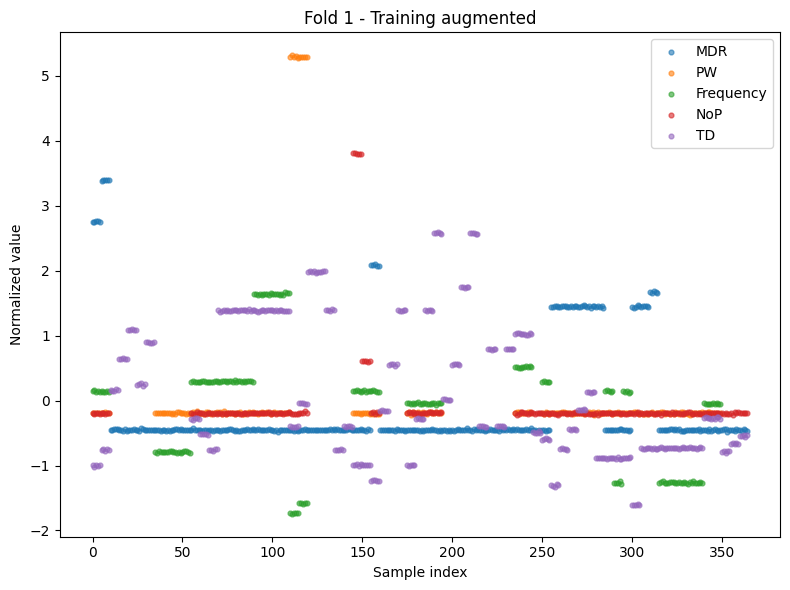

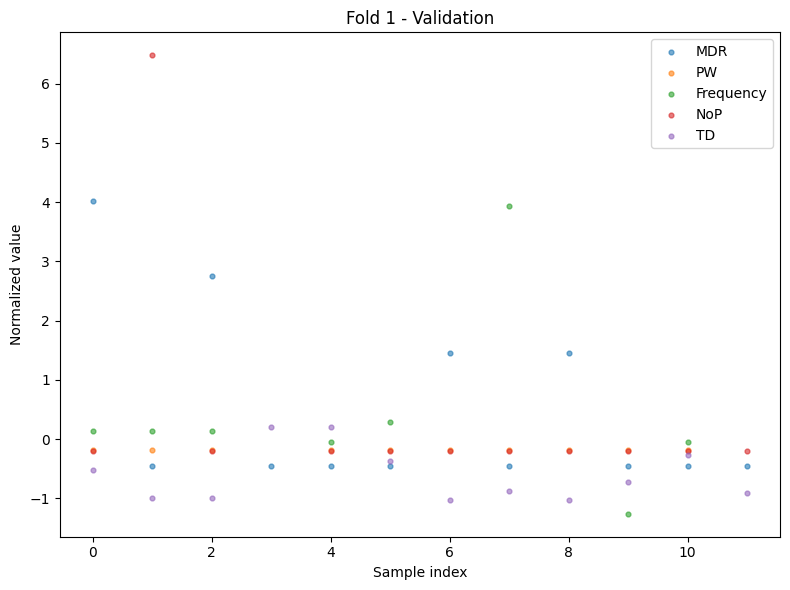

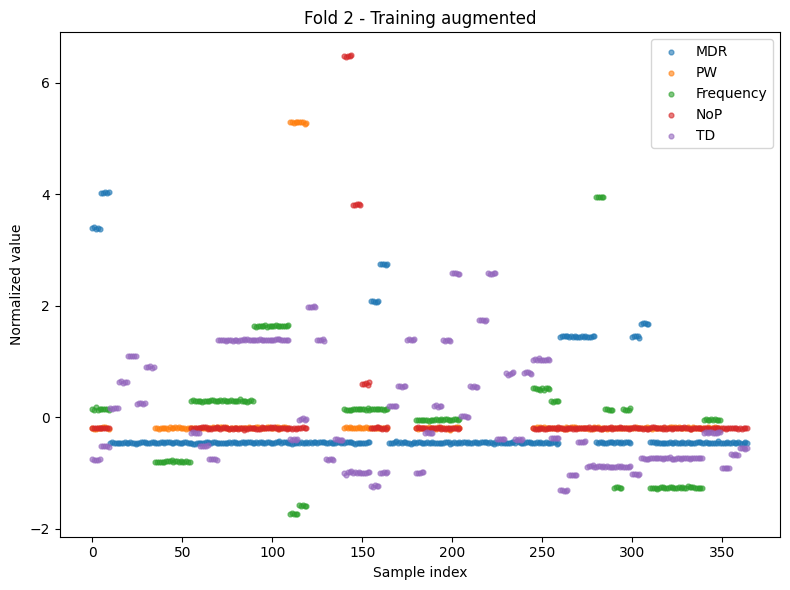

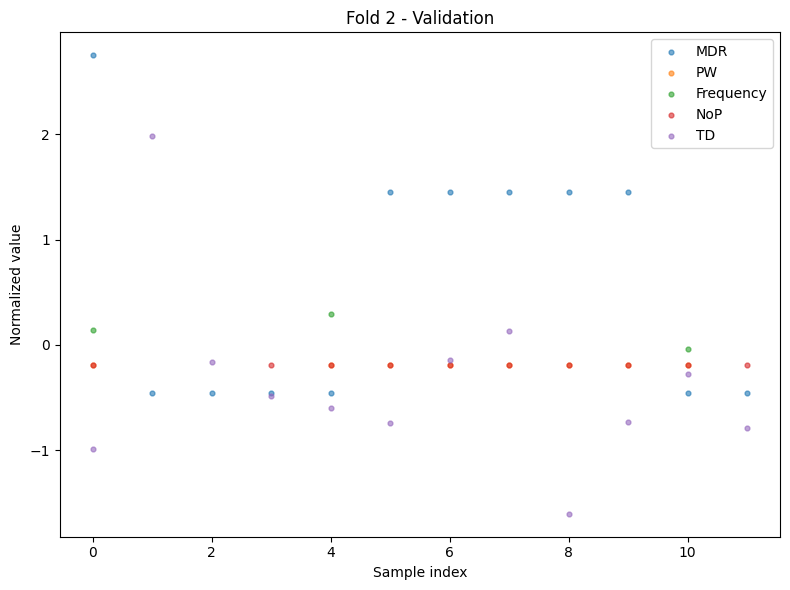

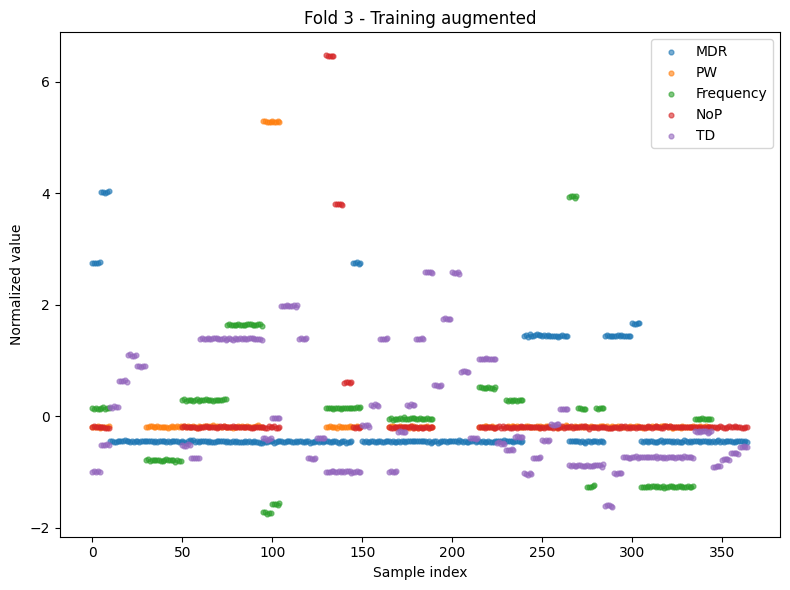

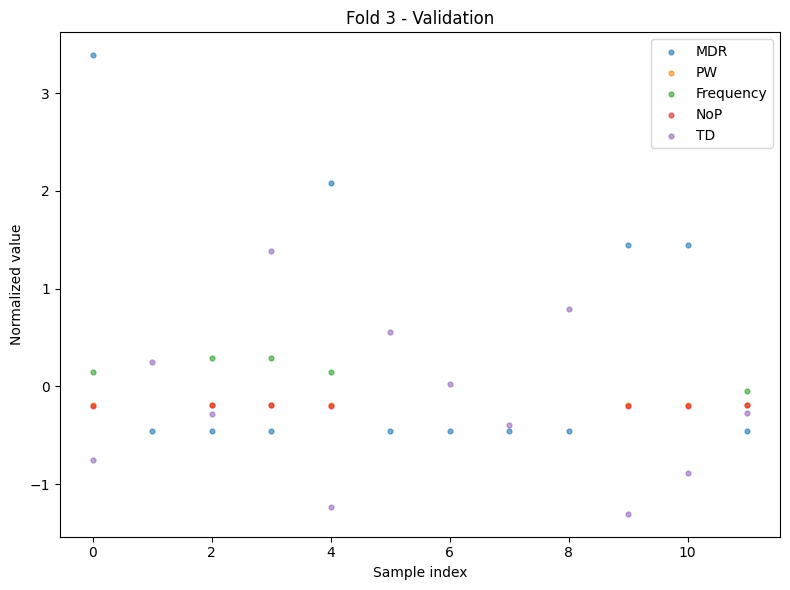

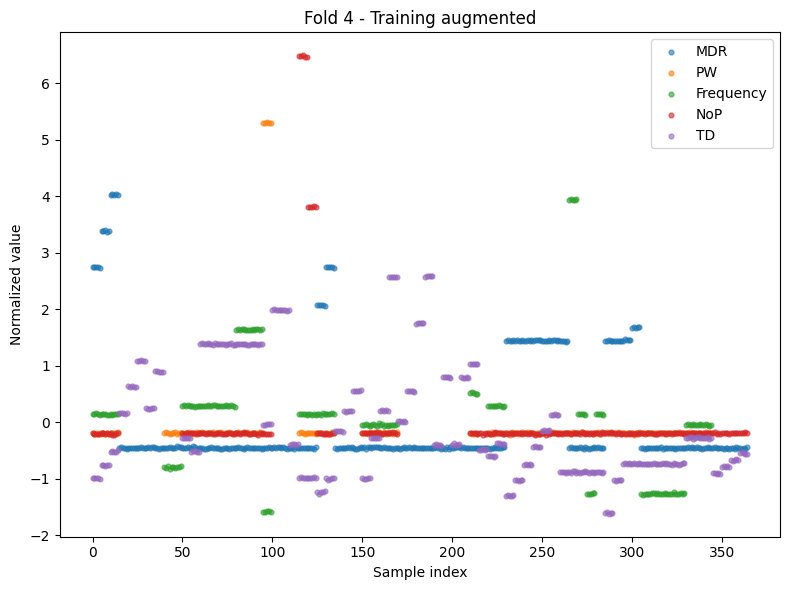

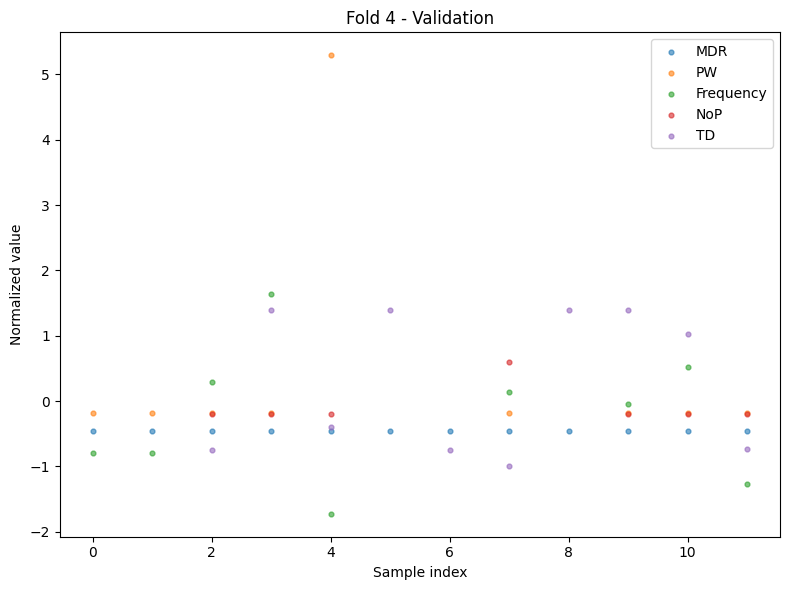

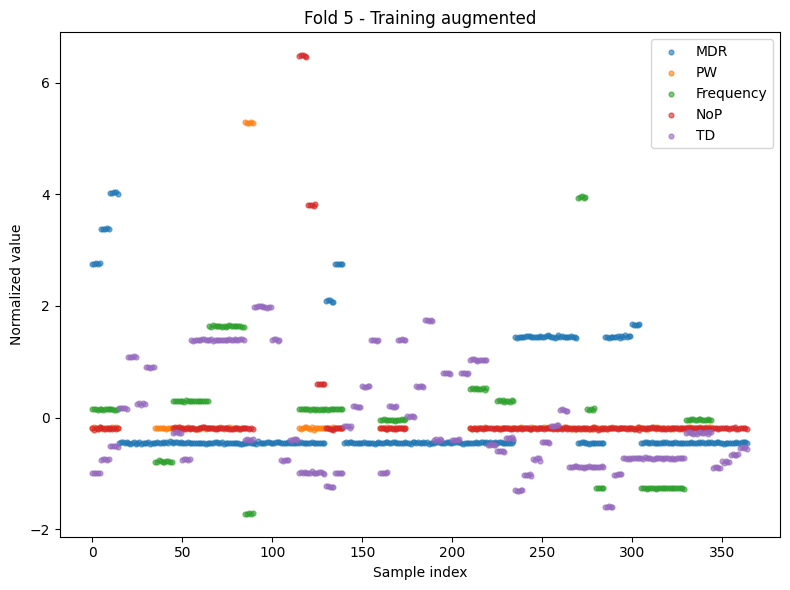

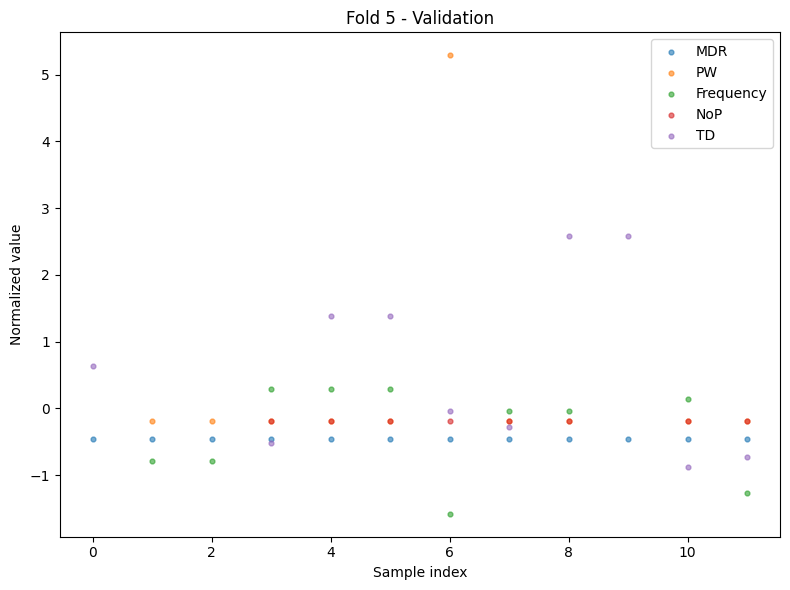

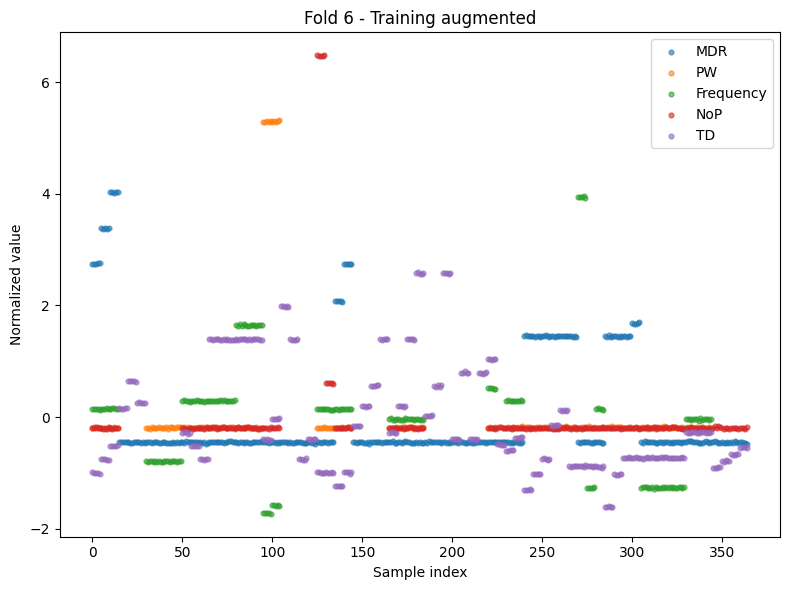

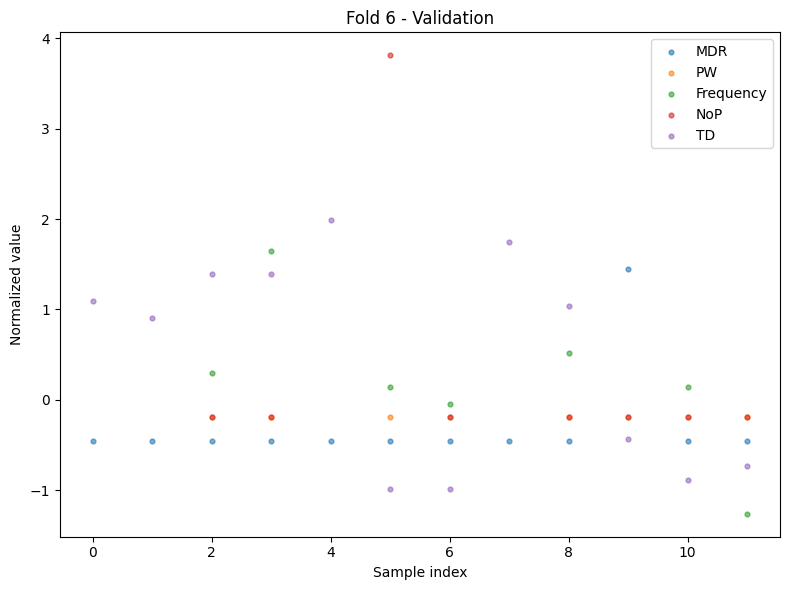

In [18]:
from src.models.augmentation_df import plot_feature_distributions

for i in range(number_of_folds):
    plot_feature_distributions(
    datasets[i]["X_train"],
    title=f"Fold {i} - Training augmented"
    )
    plot_feature_distributions(
    datasets[i]["X_val"],
    title=f"Fold {i} - Validation"
    )


In [ ]:
""" 
A Grid Search was performed to identify the optimal model parameters, using accuracy as the scoring metric. While this approach 
proved effective, alternative evaluation metrics (such as f1 or auc) could be considered in future work.
"""

In [19]:
from sklearn.ensemble import RandomForestClassifier
param_grid ={
    'n_estimators': [1000],
    'max_depth': [None],
    'min_samples_split': [2],
    'min_samples_leaf': [1, 2]
}
#k=7, 1000, none, 2,1

In [20]:
from src.models.augmentation_df import grid_search_classification

search = grid_search_classification(
    datasets=datasets,
    model_class=RandomForestClassifier,
    param_grid=param_grid,
    scoring="accuracy"
)

print("Best parameters:", search["best_params"])
print("Best scores:", search["best_scores"])


Best parameters: {'n_estimators': 1000, 'max_depth': None, 'min_samples_split': 2, 'min_samples_leaf': 1}
Best scores: {'params': {'n_estimators': 1000, 'max_depth': None, 'min_samples_split': 2, 'min_samples_leaf': 1}, 'accuracy_mean': np.float64(0.717032967032967), 'accuracy_std': np.float64(0.12582164315423214), 'f1_mean': np.float64(0.6992045302969672), 'f1_std': np.float64(0.1398982251709608), 'auc_mean': np.float64(0.7096938775510205), 'auc_std': np.float64(0.10917652084143553)}


In [ ]:
"""
Metrics for each fold and mean values.
"""

In [21]:
from src.models.augmentation_df import evaluate_classification_folds
best_model_rf = RandomForestClassifier(**search["best_params"])

results = evaluate_classification_folds(
    datasets=datasets,
    model=best_model_rf
)

Fold 0:
  Accuracy: 0.6923
  F1-score: 0.6905
  ROC AUC:  0.6750
----------------------------------------
Fold 1:
  Accuracy: 0.8333
  F1-score: 0.8333
  ROC AUC:  0.7714
----------------------------------------
Fold 2:
  Accuracy: 0.9167
  F1-score: 0.9111
  ROC AUC:  0.9143
----------------------------------------
Fold 3:
  Accuracy: 0.5833
  F1-score: 0.5804
  ROC AUC:  0.6571
----------------------------------------
Fold 4:
  Accuracy: 0.7500
  F1-score: 0.7483
  ROC AUC:  0.7714
----------------------------------------
Fold 5:
  Accuracy: 0.5833
  F1-score: 0.4958
  ROC AUC:  0.5571
----------------------------------------
Fold 6:
  Accuracy: 0.5833
  F1-score: 0.5804
  ROC AUC:  0.6286
----------------------------------------

=== SUMMARY ===
Accuracy: mean=0.7060, std=0.1241
F1-score: mean=0.6914, std=0.1386
ROC AUC:  mean=0.7107, std=0.1091


In [ ]:
""" 
ROC and AUC plots
"""

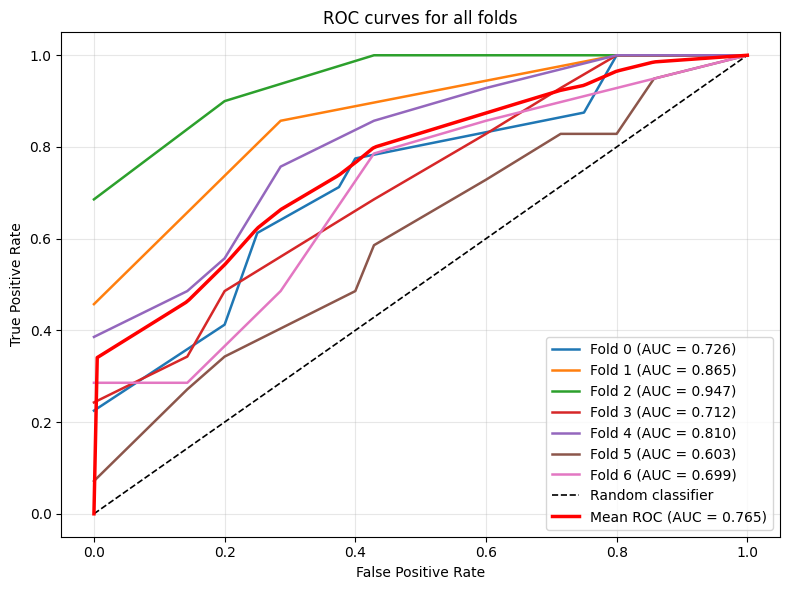

In [22]:
from src.models.augmentation_df import plot_roc
plot_roc(results)

In [ ]:
"""
Model feature importance and Permutation feature importance
"""


 FEATURE IMPORTANCE PER FOLD 


--- Fold 1 ---
MDR             | model=0.15032 | perm=0.00000
PW              | model=0.10872 | perm=0.00000
Frequency       | model=0.14306 | perm=0.05385
NoP             | model=0.08689 | perm=0.00000
TD              | model=0.34807 | perm=0.08462
Particle        | model=0.02260 | perm=0.03846
Target          | model=0.14033 | perm=0.27692

--- Fold 2 ---
MDR             | model=0.15032 | perm=0.01667
PW              | model=0.10872 | perm=0.07500
Frequency       | model=0.14306 | perm=0.01667
NoP             | model=0.08689 | perm=0.08333
TD              | model=0.34807 | perm=0.31667
Particle        | model=0.02260 | perm=0.00000
Target          | model=0.14033 | perm=0.07500

--- Fold 3 ---
MDR             | model=0.15032 | perm=0.00000
PW              | model=0.10872 | perm=0.05000
Frequency       | model=0.14306 | perm=0.00833
NoP             | model=0.08689 | perm=0.00000
TD              | model=0.34807 | perm=0.32500
Particle        | model=0.0

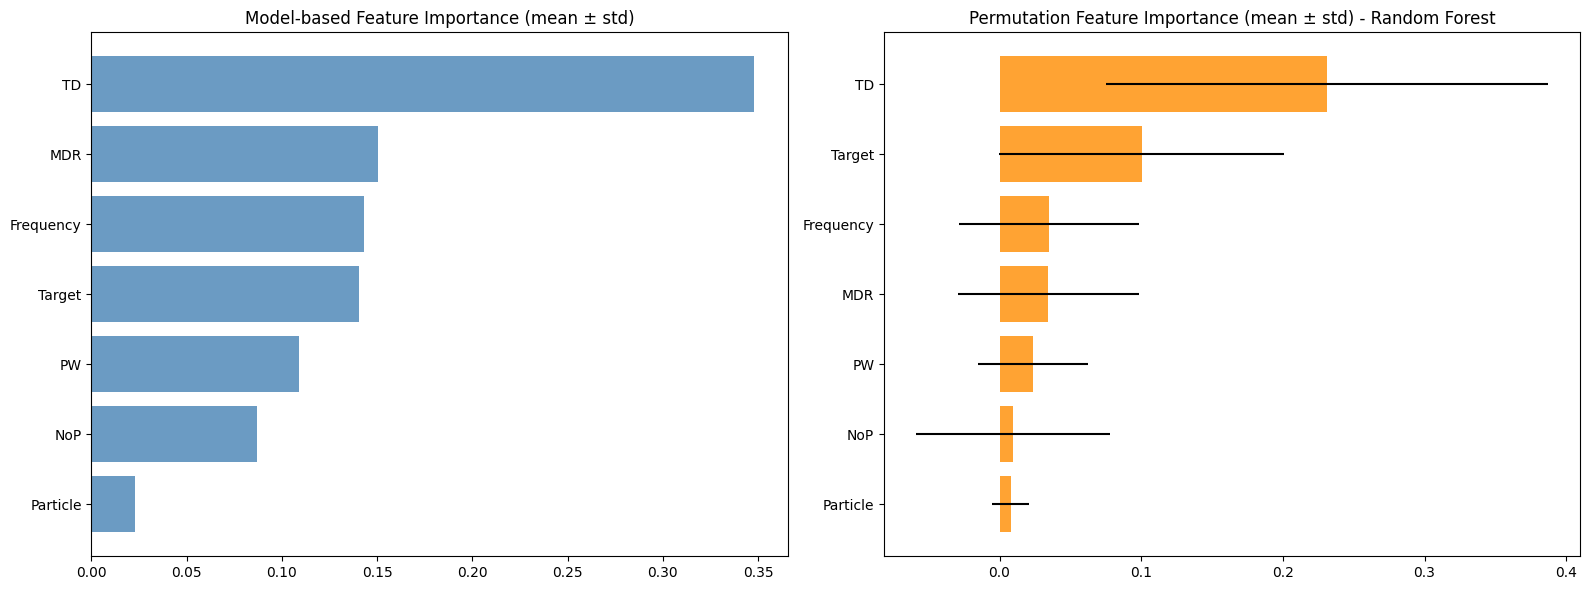

In [23]:
from src.models.augmentation_df import plot_feature_importances_across_folds
plot_feature_importances_across_folds(
    model=best_model_rf,
    datasets=datasets,
    model_name="Random Forest",
)



In [ ]:
"""
SHAP feature importance with SHAP summary plot for each fold. 
"""


 SHAP FEATURE IMPORTANCE PER FOLD 

SHAP array shape: (13, 7, 2)

Feature ranking:
Target               0.137732
TD                   0.132823
Frequency            0.069447
PW                   0.041095
NoP                  0.036451
Particle             0.028100
MDR                  0.021407

Generating SHAP summary plot...


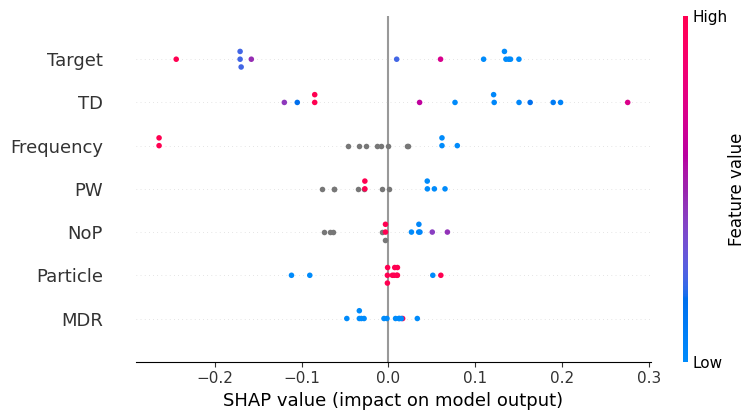

SHAP array shape: (12, 7, 2)

Feature ranking:
TD                   0.208112
Target               0.084634
Frequency            0.057723
NoP                  0.053928
PW                   0.048423
MDR                  0.041231
Particle             0.007277

Generating SHAP summary plot...


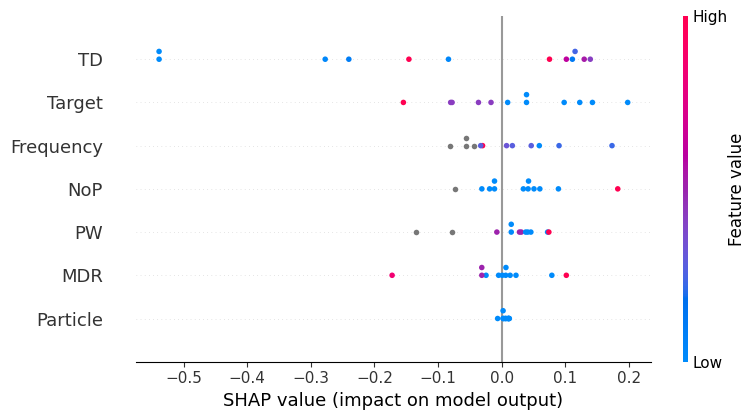

SHAP array shape: (12, 7, 2)

Feature ranking:
TD                   0.175287
Target               0.129984
PW                   0.052353
NoP                  0.038180
MDR                  0.030990
Frequency            0.028498
Particle             0.015083

Generating SHAP summary plot...


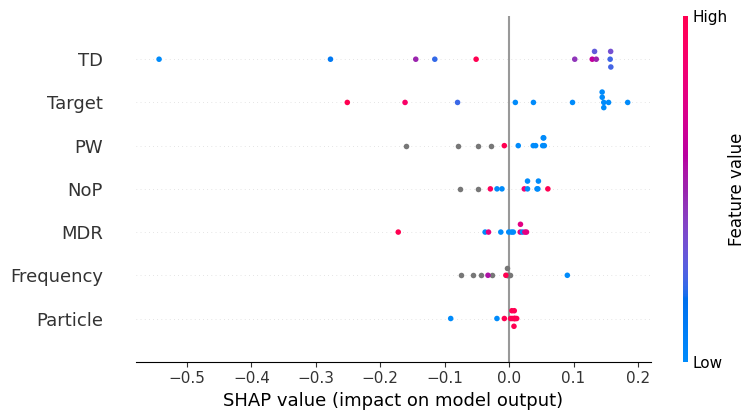

SHAP array shape: (12, 7, 2)

Feature ranking:
TD                   0.181202
Target               0.098853
MDR                  0.053278
Frequency            0.034240
PW                   0.028824
NoP                  0.028488
Particle             0.022521

Generating SHAP summary plot...


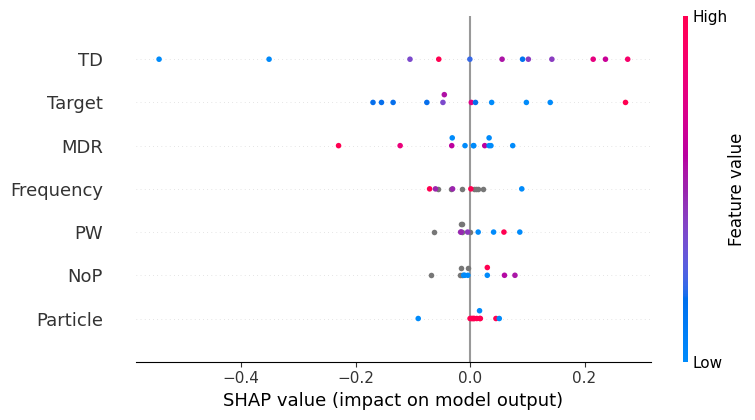

SHAP array shape: (12, 7, 2)

Feature ranking:
TD                   0.099897
Target               0.088192
Frequency            0.086799
PW                   0.052063
NoP                  0.042553
MDR                  0.039580
Particle             0.019789

Generating SHAP summary plot...


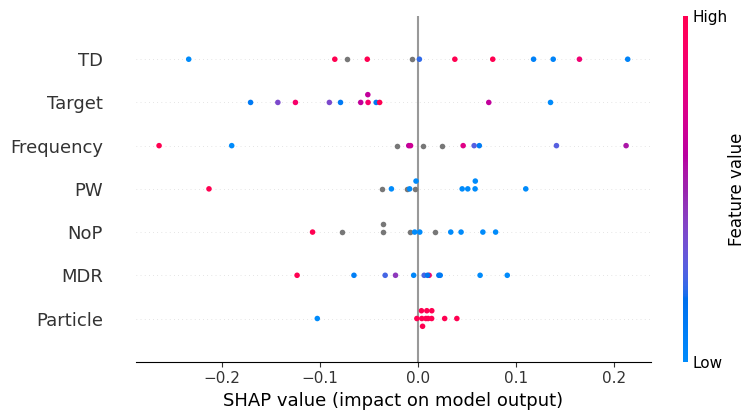

SHAP array shape: (12, 7, 2)

Feature ranking:
Target               0.116748
Frequency            0.101892
PW                   0.064464
TD                   0.063222
NoP                  0.040943
MDR                  0.022421
Particle             0.016855

Generating SHAP summary plot...


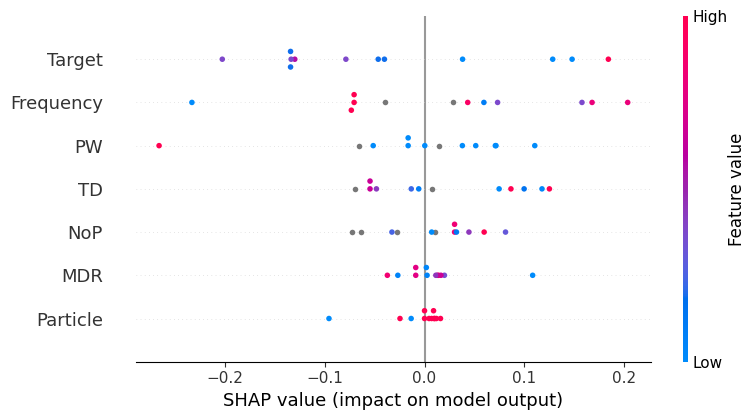

SHAP array shape: (12, 7, 2)

Feature ranking:
Target               0.135183
TD                   0.108466
Frequency            0.064046
NoP                  0.049190
PW                   0.042398
Particle             0.023880
MDR                  0.019490

Generating SHAP summary plot...


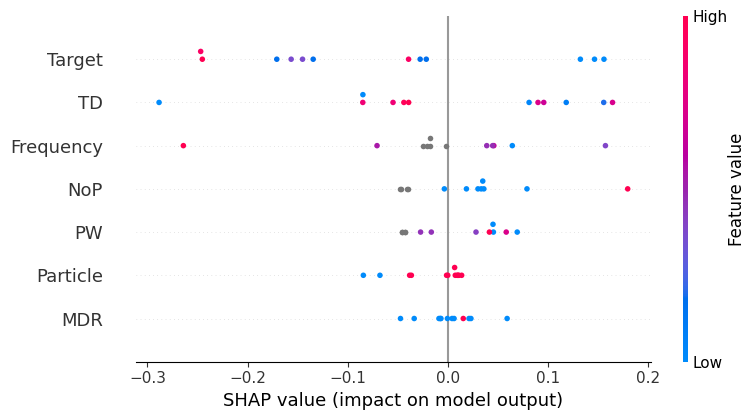


 SHAP IMPORTANCE (MEAN ± STD)

TD                   mean=0.138430 std=0.047979
Target               mean=0.113047 std=0.020793
Frequency            mean=0.063235 std=0.024398
PW                   mean=0.047089 std=0.010335
NoP                  mean=0.041390 std=0.007753
MDR                  mean=0.032628 std=0.011675
Particle             mean=0.019072 std=0.006290


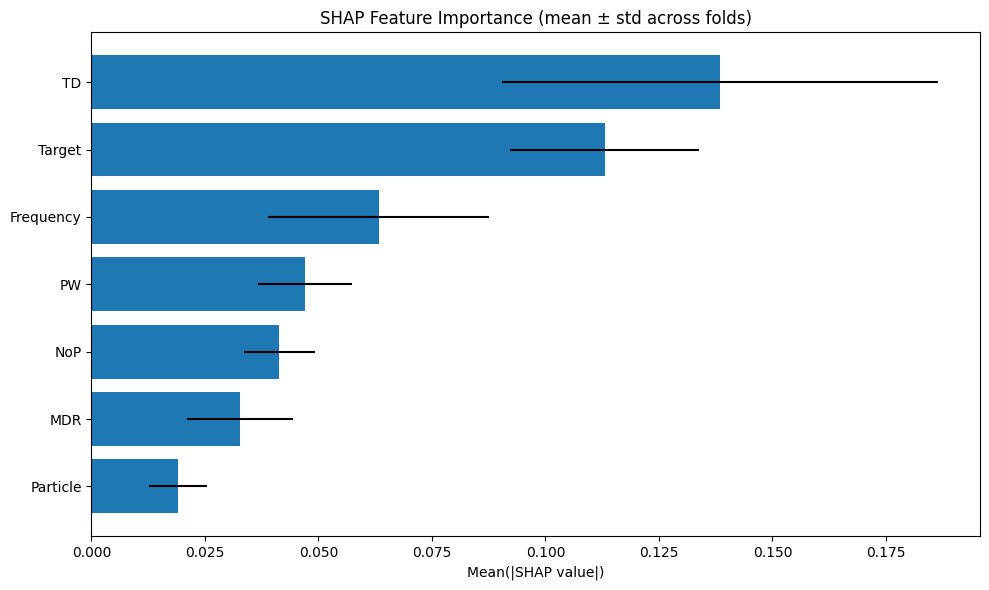

In [24]:
from src.models.augmentation_df import shap_summary_across_folds
shap_summary_across_folds(
    model=best_model_rf,
    datasets=datasets,
    max_display=20
)